## Chargement des données

Import des bibliothèques nécessaires (pandas, numpy, matplotlib, seaborn),
fixation de la graine aléatoire pour la reproductibilité, puis chargement
du dataset Telco Customer Churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print("Shape :", df.shape)
df.head()

Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Profiling

Vérification des types de colonnes détectés par pandas.

In [2]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### `TotalCharges` — colonne mal typée

`TotalCharges` est chargée comme texte (`object`) alors qu'elle devrait
être numérique. Identifions les lignes qui posent problème.

In [3]:
bad_mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(df.loc[bad_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]].to_string())
print(f"\n{bad_mask.sum()} lignes concernées.")

      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             

11 lignes concernées.


### Conversion et mesure des valeurs manquantes

Conversion de `TotalCharges` en numérique, puis calcul du % de NA sur
l'ensemble des colonnes.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

na_pct = (df.isna().mean() * 100).round(2)
print("% de valeurs manquantes par colonne :")
print(na_pct[na_pct > 0])

% de valeurs manquantes par colonne :
TotalCharges    0.16
dtype: float64


### Doublons

Vérification de l'absence de lignes ou d'identifiants clients dupliqués.

In [5]:
print("Lignes dupliquées (toutes colonnes) :", df.duplicated().sum())
print("customerID dupliqués :", df["customerID"].duplicated().sum())

Lignes dupliquées (toutes colonnes) : 0
customerID dupliqués : 0


### Features quasi-constantes

Recherche de colonnes dont une seule modalité domine (>95%), peu
informatives pour le modèle.

In [6]:
print("Features quasi-constantes (modalité dominante > 95%) :")
found = False
for col in df.columns:
    if df[col].dtype == object and col != "customerID":
        top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_share > 0.95:
            print(f"  {col}: {top_share:.1%}")
            found = True
if not found:
    print("  Aucune — pas de feature quasi-constante à retirer.")

Features quasi-constantes (modalité dominante > 95%) :
  Aucune — pas de feature quasi-constante à retirer.


### Corrélations entre variables numériques

                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.25          0.83
MonthlyCharges    0.25            1.00          0.65
TotalCharges      0.83            0.65          1.00


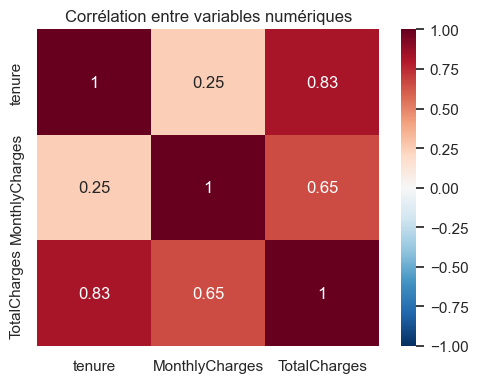

In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[num_cols].corr(numeric_only=True)
print(corr.round(2))

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Corrélation entre variables numériques")
plt.tight_layout()
plt.show()

## 2. Détection de fuite de données

Mesure du pouvoir prédictif de chaque variable prise isolément (AUC en
validation croisée). Une vraie fuite donnerait un AUC proche de 1.0 pour
une seule variable.

In [8]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

target = (df["Churn"] == "Yes").astype(int)
work = df.drop(columns=["customerID", "Churn"]).copy()
work["TotalCharges"] = work["TotalCharges"].fillna(work["TotalCharges"].median())

cat_cols = work.select_dtypes(include="object").columns.tolist()
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
work_enc = work.copy()
work_enc[cat_cols] = enc.fit_transform(work[cat_cols])

single_feature_auc = {}
for col in work_enc.columns:
    scores = cross_val_score(LogisticRegression(max_iter=1000),
                              work_enc[[col]].values, target,
                              cv=5, scoring="roc_auc")
    single_feature_auc[col] = scores.mean()

leak_check = pd.Series(single_feature_auc).sort_values(ascending=False)
print(leak_check.round(3).head(10))

tenure              0.740
Contract            0.739
OnlineSecurity      0.683
TechSupport         0.678
TotalCharges        0.652
OnlineBackup        0.624
MonthlyCharges      0.621
DeviceProtection    0.613
PaperlessBilling    0.607
Dependents          0.585
dtype: float64


Conclusion à retenir : pas de fuite détectée. Seul customerID est à exclure des features (c'est juste un identifiant, sans pouvoir prédictif réel).

## 3. Analyse bivariée

Taux de churn (%) par modalité pour les variables catégorielles clés.

In [9]:
for col in ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]:
    rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).round(1)
    print(f"\n--- Taux de churn (%) par {col} ---")
    print(rate)


--- Taux de churn (%) par Contract ---
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

--- Taux de churn (%) par InternetService ---
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

--- Taux de churn (%) par PaymentMethod ---
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1
Name: Churn, dtype: float64

--- Taux de churn (%) par SeniorCitizen ---
SeniorCitizen
0    23.6
1    41.7
Name: Churn, dtype: float64


### Information mutuelle — classement des features les plus prédictives

Top 10 features par information mutuelle avec Churn :
Contract            0.0985
tenure              0.0725
OnlineSecurity      0.0647
TechSupport         0.0630
InternetService     0.0556
OnlineBackup        0.0468
MonthlyCharges      0.0458
PaymentMethod       0.0445
TotalCharges        0.0441
DeviceProtection    0.0439
dtype: float64


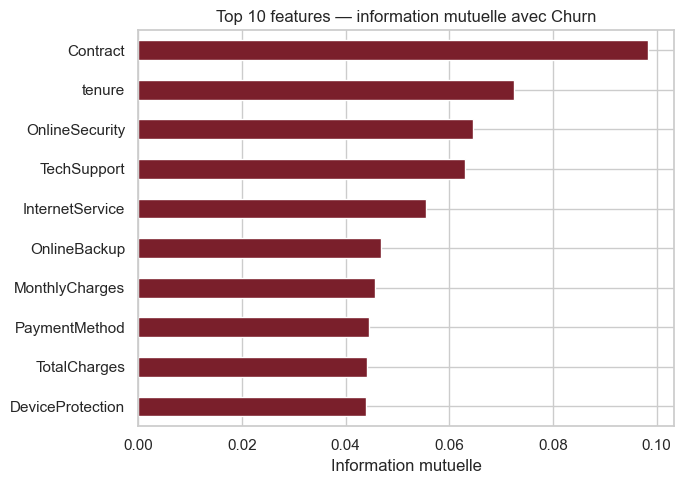

In [10]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    work_enc, target,
    discrete_features=[c in cat_cols for c in work_enc.columns],
    random_state=RANDOM_STATE,
)
mi_series = pd.Series(mi, index=work_enc.columns).sort_values(ascending=False)
print("Top 10 features par information mutuelle avec Churn :")
print(mi_series.head(10).round(4))

plt.figure(figsize=(7, 5))
mi_series.head(10).sort_values().plot(kind="barh", color="#7a1f2b")
plt.title("Top 10 features — information mutuelle avec Churn")
plt.xlabel("Information mutuelle")
plt.tight_layout()
plt.show()

## 4. Hypothèses métier — vérification graphique

H1 : contrat mensuel → churn plus élevé.
H2 : faible ancienneté → churn plus élevé.
H3 : fibre optique → churn plus élevé.
H4 : chèque électronique → churn plus élevé.

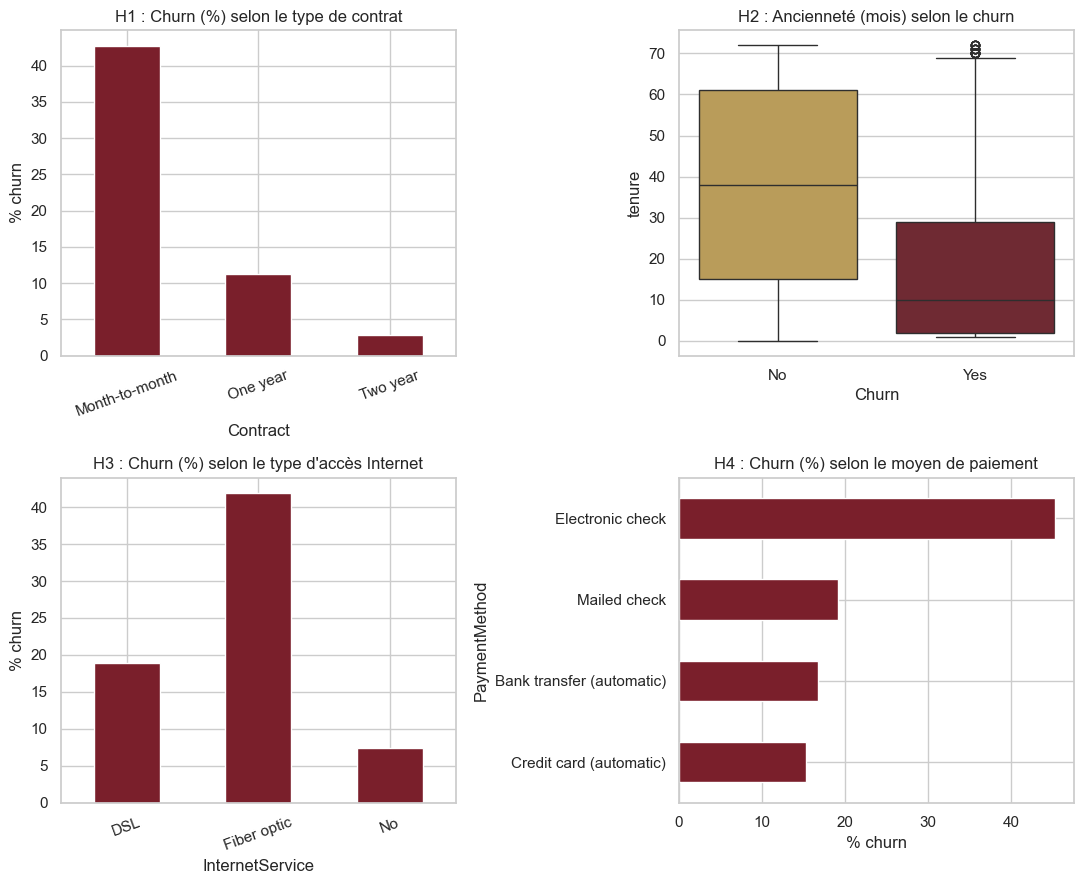

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

rate_contract = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
rate_contract = rate_contract.reindex(["Month-to-month", "One year", "Two year"])
rate_contract.plot(kind="bar", ax=axes[0, 0], color="#7a1f2b")
axes[0, 0].set_title("H1 : Churn (%) selon le type de contrat")
axes[0, 0].set_ylabel("% churn")
axes[0, 0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", ax=axes[0, 1],
            palette=["#c9a24a", "#7a1f2b"], legend=False)
axes[0, 1].set_title("H2 : Ancienneté (mois) selon le churn")

rate_internet = df.groupby("InternetService")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
rate_internet.plot(kind="bar", ax=axes[1, 0], color="#7a1f2b")
axes[1, 0].set_title("H3 : Churn (%) selon le type d'accès Internet")
axes[1, 0].set_ylabel("% churn")
axes[1, 0].tick_params(axis='x', rotation=20)

rate_pay = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
rate_pay.plot(kind="barh", ax=axes[1, 1], color="#7a1f2b")
axes[1, 1].set_title("H4 : Churn (%) selon le moyen de paiement")
axes[1, 1].set_xlabel("% churn")

plt.tight_layout()
plt.show()

### H5 : Absence de support technique → churn plus élevé

In [12]:
rate_support = df.groupby("TechSupport")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
print("H5 — Churn (%) selon TechSupport :")
print(rate_support.round(1))

print("\nTenure médiane churners vs non-churners :")
print(df.groupby("Churn")["tenure"].median())

H5 — Churn (%) selon TechSupport :
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Churn, dtype: float64

Tenure médiane churners vs non-churners :
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64


### Verdict des 5 hypothèses

| # | Hypothèse | Résultat observé | Verdict |
|---|---|---|---|
| H1 | Contrat mensuel → churn plus élevé | 42,7 % (mensuel) vs 11,3 % (1 an) vs 2,8 % (2 ans) | **Confirmée**, très nettement |
| H2 | Faible ancienneté → churn plus élevé | Médiane 10 mois (churners) vs 38 mois (non-churners) | **Confirmée** |
| H3 | Fibre optique → churn plus élevé | 41,9 % (fibre) vs 19,0 % (DSL) vs 7,4 % (pas d'internet) | **Confirmée** |
| H4 | Chèque électronique → churn plus élevé | 45,3 % (chèque électronique) vs 15-19 % (autres moyens) | **Confirmée**, écart le plus marqué |
| H5 | Pas de support technique → churn plus élevé | 41,6 % (sans support) vs 15,2 % (avec support) | **Confirmée** |

Les 5 hypothèses sont validées graphiquement et numériquement. Elles
guideront le feature engineering de la Mission 2 (ex. regrouper
`tenure` en tranches, croiser `Contract` × `PaymentMethod`, compter le
nombre de services de protection souscrits).

## 5. Synthèse — 3 insights majeurs

1. **Le type de contrat est de loin le facteur le plus discriminant**
   (information mutuelle la plus élevée, écart de churn de 2,8 % à 42,7 %) :
   les clients sans engagement (mensuel) sont la cible prioritaire de la
   campagne de rétention.
2. **L'ancienneté et le churn sont fortement liés** (médiane 10 mois vs 38 mois) —
   les nouveaux clients (moins de 12 mois) constituent une population à
   risque à surveiller de près, en cohérence avec H2.
3. **Le mode de paiement et le manque de services de protection/support
   sont des signaux secondaires mais robustes** : le paiement par chèque
   électronique (45,3 % de churn) et l'absence de `TechSupport`/`OnlineSecurity`
   trahissent un lien client plus faible, probablement en partie parce que
   ces clients sont aussi plus souvent en contrat mensuel (à approfondir en
   Mission 2 avec des features croisées).

Aucune fuite de données détectée. Une seule colonne nécessite un traitement
spécifique (`TotalCharges`, 0,16 % de NA, à imputer dans le pipeline,
train uniquement).